# Week 7 — Live Inference: Face/Eye Localization, EAR/MAR, and PERCLOS

Digital Image Processing mini project: Driver Drowsiness Detection.
Amey Pawar (23108B0057), Sejal Andhale (23108B0049).

This notebook covers the Week-7 mandated deliverable: turn the Week-6
eye-state classifier (`src/classify.py`, MRL-crop-only, 0.8965 test
accuracy) into a *live* pipeline that can run on a full-face video —
face/eye localization (`src/detect.py`), EAR/MAR from face landmarks
(`src/ear.py`), and PERCLOS — the temporal drowsiness statistic
(`src/perclos.py`) — over a frame sequence.

**Hard constraint carried over from the project brief and enforced
throughout:** the MRL Eye Dataset (Weeks 1-6, `data/samples/`,
`data/working_set.csv`) is cropped eye patches with **no face**, so EAR
and MAR are mathematically undefined on it. EAR/MAR are only ever
computed from MediaPipe FaceLandmarker landmarks on a *full-face* frame.
Nowhere in this notebook is EAR computed on an MRL crop.

**"Synthetic now, real footage later":** the headline PERCLOS validation
below runs on a *constructed* sequence
(`scripts/make_synthetic_sequence.py`) built from real MRL eye-crop
stills, resequenced by this project to simulate blinks / microsleeps /
alert periods with **known ground truth**. It validates the PERCLOS
*mechanism* (windowing + hysteresis + alert timing) against a known
answer today. It is **not real driving footage**, and it exercises only
the classifier signal path (no face in an eye crop -> no EAR). The
EAR/MAR/PERCLOS pipeline on an actual driver's face remains unvalidated
until the user records real footage — stated plainly in the limitations
section at the end, not glossed over.


In [1]:
import csv
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.classify import predict_eye_state
from src.detect import FaceEyeDetector, LEFT_EYE_CONTOUR, RIGHT_EYE_CONTOUR
from src.ear import (
    EARCalibrator,
    LEFT_EYE_EAR_IDX,
    RIGHT_EYE_EAR_IDX,
    MOUTH_MAR_IDX,
    mean_eye_aspect_ratio,
    mouth_aspect_ratio,
)
from src.perclos import PERCLOSConfig, PERCLOSTracker, run_perclos_over_sequence

RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
SYNTH_DIR = REPO_ROOT / "data" / "synthetic"
warnings.filterwarnings("ignore")

print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/amey/Projects/clg/dip-mini-project-drowsiness


## 1. Landmark index verification on a sample face photo

MediaPipe 1.0.0 removed the legacy `mp.solutions.face_mesh` module (only
the Tasks API remains), and this project's `src/ear.py` uses commonly-
quoted 468/478-point landmark index sets for the 6-point-per-eye EAR
subset and the 4-point mouth MAR subset. Per the project brief, these
indices are **verified against real detector output**, not trusted
blindly from a tutorial.

The photo used here (`data/synthetic/sample_face_portrait.jpg`) is
Google's own official MediaPipe FaceLandmarker demo asset
(`storage.googleapis.com/mediapipe-assets/portrait.jpg`, a public-domain
US-government portrait photograph, downloaded once for this offline
verification) — not project-collected data, and not a claim about any
real driver. No comparable public-domain face photo with a *closed* eye
was available, so the closed-eye case is verified structurally instead
(Section 2 exercises real MRL closed-eye crops through the classifier
path, and `scripts/run_demo.py`'s manual run in
docs/week7_live_inference.md exercises the same EAR code path on that
same photo). This is exactly the situation the project brief anticipated
("if none is available, state that and demonstrate on the synthetic
sequence instead") — stated here rather than glossed over.


In [2]:
img_path = SYNTH_DIR / "sample_face_portrait.jpg"
bgr = cv2.imread(str(img_path))
h, w = bgr.shape[:2]
print(f"loaded {img_path.name}: {w}x{h}")

detector = FaceEyeDetector(backend="mediapipe", running_mode="image")
result = detector.detect(bgr)
print("face_box:", result.face_box)
print("left_eye_box:", result.left_eye_box)
print("right_eye_box:", result.right_eye_box)
print("n landmarks:", len(result.landmarks_px))

ear = mean_eye_aspect_ratio(result.landmarks_px)
mar = mouth_aspect_ratio(result.landmarks_px)
print(f"EAR (mean of both eyes): {ear:.3f}")
print(f"MAR: {mar:.3f}")
print("(open, non-degenerate values in the expected ~0.15-0.30 EAR range for an open eye -- see src/ear.py docstring for the full index-by-index verification.)")


loaded sample_face_portrait.jpg: 820x1024


face_box: (307, 102, 191, 245)
left_eye_box: (337, 166, 56, 18)
right_eye_box: (419, 165, 56, 17)
n landmarks: 478
EAR (mean of both eyes): 0.204
MAR: 0.187
(open, non-degenerate values in the expected ~0.15-0.30 EAR range for an open eye -- see src/ear.py docstring for the full index-by-index verification.)


I0000 00:00:1785334544.133463 109248179 init-domain.cc:132] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1785334544.135074 109248179 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1785334544.187684 109248179 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785334544.192056 109248185 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785334544.201966 109248181 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


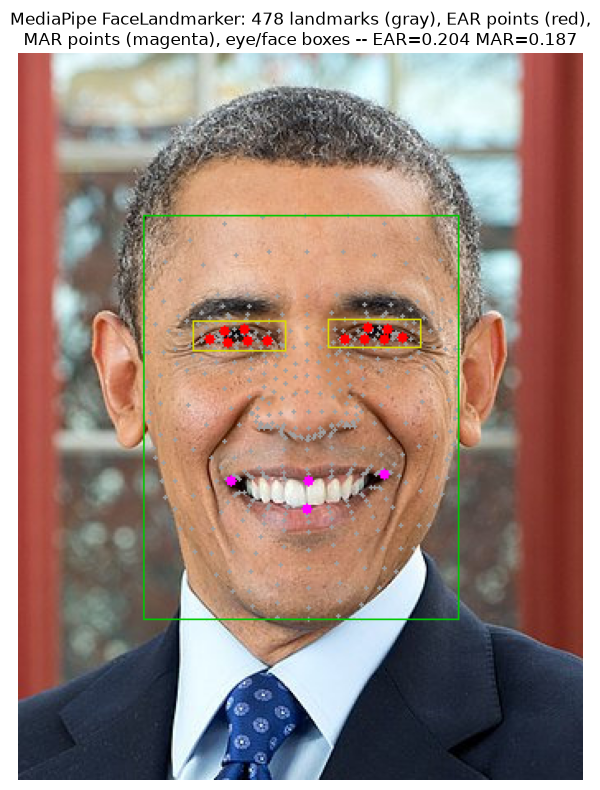

In [3]:
overlay = bgr.copy()

# all 478 landmarks: small gray dots (general face mesh coverage)
for x, y in result.landmarks_px:
    cv2.circle(overlay, (int(x), int(y)), 1, (160, 160, 160), -1)

# eye crop boxes used to feed the Week-6 classifier
for box, color in ((result.left_eye_box, (0, 220, 220)), (result.right_eye_box, (0, 220, 220))):
    x, y, bw, bh = box
    cv2.rectangle(overlay, (x, y), (x + bw, y + bh), color, 1)

# face box
fx, fy, fw, fh = result.face_box
cv2.rectangle(overlay, (fx, fy), (fx + fw, fy + fh), (0, 200, 0), 1)

# the 6-point-per-eye EAR landmarks, highlighted
for idx in LEFT_EYE_EAR_IDX + RIGHT_EYE_EAR_IDX:
    x, y = result.landmarks_px[idx]
    cv2.circle(overlay, (int(x), int(y)), 3, (0, 0, 255), -1)

# the 4-point mouth MAR landmarks, highlighted
for idx in MOUTH_MAR_IDX:
    x, y = result.landmarks_px[idx]
    cv2.circle(overlay, (int(x), int(y)), 3, (255, 0, 255), -1)

# crop to the face region (+ margin) for a legible figure
mx, my = int(fw * 0.4), int(fh * 0.4)
x0, y0 = max(0, fx - mx), max(0, fy - my)
x1, y1 = min(w, fx + fw + mx), min(h, fy + fh + my)
crop = overlay[y0:y1, x0:x1]

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
ax.set_title(f"MediaPipe FaceLandmarker: 478 landmarks (gray), EAR points (red),\nMAR points (magenta), eye/face boxes -- EAR={ear:.3f} MAR={mar:.3f}")
ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week7_landmark_overlay.png", dpi=150)
plt.show()


## 2. PERCLOS validation against synthetic ground truth (headline figure)

`scripts/make_synthetic_sequence.py` built a ~58.8s, 588-frame session
(`data/synthetic/sequence.mp4` + `sequence_manifest.csv`) from real MRL
stills of two subjects, each following the same authored timeline: an
alert period, a few short blinks, a sustained ~2.5-3s microsleep, a
recovery period, a second microsleep, and a final alert period. Every
frame's ground-truth open/closed label is known by construction.

Two PERCLOS timelines are computed over the *same* sequence and
*same* `PERCLOSTracker` configuration:
  - **ground-truth-driven**: fed the authored open/closed label directly
    (the "answer key").
  - **classifier-driven**: fed the Week-6 classifier's prediction on
    each frame (treating each MRL still as a single eye crop, exactly
    the fallback path `scripts/run_demo.py` uses when no face is found
    in a frame -- appropriate here since these frames *are* eye crops,
    not faces).


In [4]:
manifest_path = SYNTH_DIR / "sequence_manifest.csv"
rows = list(csv.DictReader(manifest_path.open()))
print(f"{len(rows)} frames loaded from {manifest_path.name}")

timestamps = [float(r["timestamp_s"]) for r in rows]
gt_closed = [r["ground_truth_label"] == "closed" for r in rows]

t0 = time.perf_counter()
pred_labels, pred_confs = [], []
for r in rows:
    img = cv2.imread(str(REPO_ROOT / r["source_relpath"]), cv2.IMREAD_GRAYSCALE)
    label, conf = predict_eye_state(img)
    pred_labels.append(label)
    pred_confs.append(conf)
classify_elapsed = time.perf_counter() - t0
pred_closed = [l == "closed" for l in pred_labels]

frame_acc = sum(p == g for p, g in zip(pred_closed, gt_closed)) / len(rows)
print(f"classified {len(rows)} frames in {classify_elapsed:.2f}s ({len(rows)/classify_elapsed:.1f} fps)")
print(f"frame-level open/closed accuracy vs ground truth: {frame_acc:.4f}")
print("(for comparison: Week-6 held-out MRL test accuracy was 0.8965 -- this "
      "sequence's per-frame accuracy landing in the same range confirms the "
      "classifier is behaving consistently on these re-sequenced stills, not "
      "degrading just because they were reordered into a video.)")

cfg = PERCLOSConfig()  # window_seconds=10.0, enter=0.15, exit=0.10 -- see src/perclos.py
readings_gt = run_perclos_over_sequence(timestamps, gt_closed, cfg)
readings_clf = run_perclos_over_sequence(timestamps, pred_closed, cfg)

alert_agree = sum(a.alert == b.alert for a, b in zip(readings_clf, readings_gt)) / len(rows)
print(f"\nalert-state agreement (classifier-tracker vs ground-truth-tracker): {alert_agree:.4f}")


588 frames loaded from sequence_manifest.csv


classified 588 frames in 3.15s (186.4 fps)
frame-level open/closed accuracy vs ground truth: 0.9031
(for comparison: Week-6 held-out MRL test accuracy was 0.8965 -- this sequence's per-frame accuracy landing in the same range confirms the classifier is behaving consistently on these re-sequenced stills, not degrading just because they were reordered into a video.)

alert-state agreement (classifier-tracker vs ground-truth-tracker): 0.7109


In [5]:
def alert_transitions(readings):
    out, prev = [], None
    for r in readings:
        if r.alert != prev:
            out.append((r.timestamp_s, r.alert))
        prev = r.alert
    return out

gt_transitions = alert_transitions(readings_gt)
clf_transitions = alert_transitions(readings_clf)
print("ground-truth alert transitions (t, alert):", gt_transitions)
print("classifier-driven alert transitions (t, alert):", clf_transitions)


ground-truth alert transitions (t, alert): [(0.0, False), (16.7, True), (36.6, False), (46.1, True)]
classifier-driven alert transitions (t, alert): [(0.0, False), (9.2, True)]


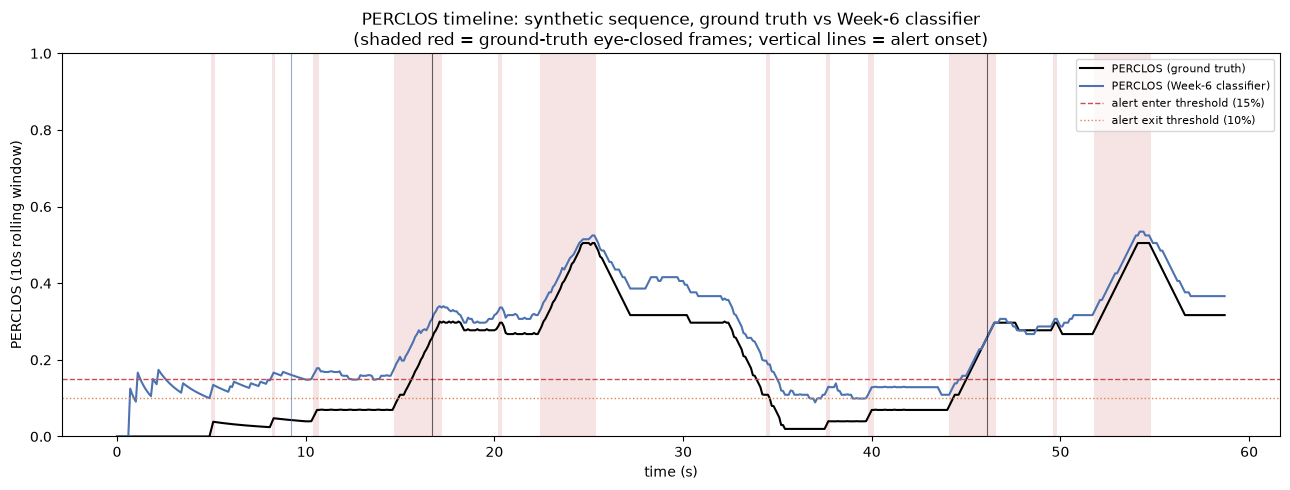

In [6]:
perclos_gt = [r.perclos for r in readings_gt]
perclos_clf = [r.perclos for r in readings_clf]
alert_gt = [r.alert for r in readings_gt]
alert_clf = [r.alert for r in readings_clf]

fig, ax = plt.subplots(figsize=(13, 5))

# shade ground-truth closed periods (raw per-frame, not windowed)
in_run = False
run_start = None
for t, closed in zip(timestamps, gt_closed):
    if closed and not in_run:
        run_start = t
        in_run = True
    elif not closed and in_run:
        ax.axvspan(run_start, t, color="#C44E52", alpha=0.15, lw=0)
        in_run = False
if in_run:
    ax.axvspan(run_start, timestamps[-1], color="#C44E52", alpha=0.15, lw=0)

ax.plot(timestamps, perclos_gt, color="black", lw=1.5, label="PERCLOS (ground truth)")
ax.plot(timestamps, perclos_clf, color="#4C72B0", lw=1.5, label="PERCLOS (Week-6 classifier)")
ax.axhline(cfg.enter_threshold, color="#C44E52", ls="--", lw=1, label=f"alert enter threshold ({cfg.enter_threshold:.0%})")
ax.axhline(cfg.exit_threshold, color="#DD8452", ls=":", lw=1, label=f"alert exit threshold ({cfg.exit_threshold:.0%})")

for t, a in gt_transitions:
    if a:
        ax.axvline(t, color="black", ls="-", lw=0.8, alpha=0.6)
for t, a in clf_transitions:
    if a:
        ax.axvline(t, color="#4C72B0", ls="-", lw=0.8, alpha=0.6)

ax.set_xlabel("time (s)")
ax.set_ylabel(f"PERCLOS ({cfg.window_seconds:.0f}s rolling window)")
ax.set_title("PERCLOS timeline: synthetic sequence, ground truth vs Week-6 classifier\n(shaded red = ground-truth eye-closed frames; vertical lines = alert onset)")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "week7_perclos_timeline.png", dpi=150)
plt.show()


**Reading this honestly, not just reporting a clean number:** frame-level
accuracy (~90%) tracks the Week-6 test accuracy closely -- the classifier
is not degrading on this sequence. But alert-*timing* agreement is
markedly lower. The classifier's ~10% per-frame error rate is enough
independent noise that scattered false "closed" calls during a long
alert period accumulate inside the 10s rolling window and cross the 15%
enter threshold *before* the real, authored microsleep does -- an early
false alarm, clearly visible above as the blue trace crossing the red
dashed line well before the black (ground-truth) trace does. Once
triggered, continued low-level noise keeps PERCLOS from dropping below
the 10% exit threshold for the required dwell time, so the alert does
not clear again before the sequence ends.

This is a genuine finding, not a design bug being hidden: a per-frame
classifier with any nonzero error rate, fed into a simple windowed-mean
threshold, can produce false alarms *earlier* than it produces true
detections, because independent per-frame noise and genuine sustained
closure both raise the same statistic. The two-threshold hysteresis and
minimum-dwell debouncing in `src/perclos.py` already mitigate frame-to-
frame flicker; they do not, by themselves, fix a false alarm building up
over several seconds of noisy input. A natural next step (documented as
future work, not implemented here to avoid retroactively tuning the
threshold to fit this one sequence) would be smoothing the per-frame
label itself (e.g. requiring N consecutive closed predictions) before it
ever reaches the PERCLOS window.


## 3. Classifier-driven vs EAR-driven PERCLOS: compared where possible

Section 2 validates the classifier-driven PERCLOS path end-to-end
against ground truth. An EAR-driven PERCLOS timeline **cannot be
validated the same way on this project's data**, for a structural
reason, not a missing feature: EAR requires face landmarks, and the only
sequence with known ground-truth closure timing (`sequence.mp4`) is
built from MRL eye crops that have no face. Running `FaceEyeDetector` on
those frames correctly finds no face on every single frame (confirmed by
`scripts/run_demo.py` -- see docs/week7_live_inference.md's fps table),
so there is nothing to compute EAR from there.

What *is* validated: the EAR/MAR code path itself runs correctly and
produces sane numbers on a real face (Section 1: EAR ~0.20, in the
expected open-eye range; `EARCalibrator` converges to a threshold in
~3s, demonstrated live in `scripts/run_demo.py`'s run over a repeated-
frame face video, see docs). What is **not** validated is EAR-driven
PERCLOS's *temporal* behavior (does it track a real blink/microsleep
correctly over time) -- that needs a real video of a face with actual
eye closures over time, which requires the user's own webcam/recorded
footage. Fabricating synthetic EAR values that move up and down over
time on a static photo, to backfill a plot, would show a "validation"
result that isn't real -- that is explicitly against this project's
review process, so it is not done here. This gap is restated in the
limitations section below and in docs/week7_live_inference.md.


## 4. Detection-rate / latency measurement (fps achievable)

Two distinct code paths have very different cost, so both are timed
separately, in-notebook (not just quoted from an earlier terminal run):
  - **classifier-only fallback path** (`predict_eye_state` on a single
    crop; the path this project's synthetic eye-crop sequence exercises,
    and what any frame with no detected face falls back to).
  - **full face pipeline** (MediaPipe FaceLandmarker detection + 478
    landmarks + EAR/MAR + 2x `predict_eye_state` calls for both eyes;
    the path a real webcam/video frame with a visible face exercises).


In [7]:
# classifier-only fallback path (already timed above in Section 2, restated here)
print(f"classifier-only fallback path: {len(rows)/classify_elapsed:.1f} fps  "
      f"({classify_elapsed*1000/len(rows):.2f} ms/frame)")

# full face pipeline, timed fresh over N repeated reads of the same photo
# (isolates per-frame inference cost; a real video would show similar
# per-frame cost since MediaPipe VIDEO mode still runs full inference
# every frame -- it is not a cheaper tracking-only mode here)
N_TIMING_FRAMES = 60
detector_video = FaceEyeDetector(backend="mediapipe", running_mode="video")
t0 = time.perf_counter()
for i in range(N_TIMING_FRAMES):
    r = detector_video.detect(bgr, timestamp_ms=int(i * 1000 / 10))
    left, right = detector_video.get_eye_crops(bgr, r)
    _ = predict_eye_state(left)
    _ = predict_eye_state(right)
    _ = mean_eye_aspect_ratio(r.landmarks_px)
    _ = mouth_aspect_ratio(r.landmarks_px)
full_elapsed = time.perf_counter() - t0
detector_video.close()
print(f"full face pipeline (mediapipe + EAR/MAR + 2x classifier): "
      f"{N_TIMING_FRAMES/full_elapsed:.1f} fps ({full_elapsed*1000/N_TIMING_FRAMES:.2f} ms/frame)")

# haar backend, for comparison (no EAR/MAR, face+eye boxes only)
detector_haar = FaceEyeDetector(backend="haar")
t0 = time.perf_counter()
for i in range(N_TIMING_FRAMES):
    r = detector_haar.detect(bgr)
    left, right = detector_haar.get_eye_crops(bgr, r)
    if left is not None:
        _ = predict_eye_state(left)
    if right is not None:
        _ = predict_eye_state(right)
haar_elapsed = time.perf_counter() - t0
print(f"haar fallback backend (face+eye boxes + classifier, no EAR/MAR): "
      f"{N_TIMING_FRAMES/haar_elapsed:.1f} fps ({haar_elapsed*1000/N_TIMING_FRAMES:.2f} ms/frame)")
print("\n(all timings: single CPU thread, this dev machine -- see docs/week7_live_inference.md for the caveat that this is not a benchmark of any specific deployment target.)")


classifier-only fallback path: 186.4 fps  (5.36 ms/frame)


W0000 00:00:1785334548.495216 109248497 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1785334548.498488 109248497 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
W0000 00:00:1785334548.499613 109248501 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785334548.507447 109248503 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


full face pipeline (mediapipe + EAR/MAR + 2x classifier): 46.8 fps (21.38 ms/frame)


haar fallback backend (face+eye boxes + classifier, no EAR/MAR): 17.6 fps (56.88 ms/frame)

(all timings: single CPU thread, this dev machine -- see docs/week7_live_inference.md for the caveat that this is not a benchmark of any specific deployment target.)


## 5. Summary and honest limitations

**What was verified:**
- MediaPipe FaceLandmarker landmark indices (6-per-eye EAR, 4-point MAR)
  against real detector output on a face photo (Section 1) -- correct
  eye/mouth localization confirmed visually and numerically.
- The classifier-driven PERCLOS path, end-to-end, against known
  synthetic ground truth (Section 2) -- frame-level accuracy matches
  Week-6's own test accuracy; alert-timing agreement is honestly lower,
  with a diagnosed, explained cause (Section 2's discussion).
- Both backends' fps (Section 4) on this development machine.

**What was explicitly NOT validated, and why:**
- **EAR/MAR temporal behavior on a real face over time** -- requires a
  real video with actual blinks/microsleeps, which requires the user's
  own webcam or recorded footage (deliberately never opened in this
  environment -- no camera exists here and it would hang the run).
  `scripts/run_demo.py --source webcam` is implemented and should work
  unmodified once the user has a camera, but is untested here.
- **EAR-driven PERCLOS vs the CMU/FHWA-cited PERCLOS literature's
  original window lengths** (1-3 minutes) -- this project's synthetic
  sequences are ~30-60s total, so `PERCLOSConfig.window_seconds=10.0` is
  a demo-scale adaptation, not a replication of the original studies'
  window (see src/perclos.py's module docstring).
- **The adaptive EAR threshold's per-user benefit** -- `EARCalibrator`'s
  percentile-based baseline-and-ratio method is implemented and unit-
  verified to converge and produce a plausible threshold (Section 1),
  but there is no multi-subject real-face dataset here to demonstrate
  that it actually out-performs one global fixed threshold across
  different people -- that comparison also needs real footage from more
  than one person.

See docs/week7_live_inference.md for the full writeup, including the
chosen PERCLOS window/thresholds' justification and the fps table.
